<a href="https://colab.research.google.com/github/aupovavernonika-ux/Ayupova-ET-212-Lab2/blob/main/%D0%90%D1%8E%D0%BF%D0%BE%D0%B2%D0%B0_%D0%95%D0%A2_212_%D0%9B%D0%B0%D0%B1%D0%B01_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Блок 1. NumPy и векторизованная обработка данных**
# Задание 1.1. Базовые свойства массивов

Анализ данных о заказах интернет-магазина.

Для каждого заказа известны: время доставки в минутах; стоимость заказа в рублях; количество товаров в заказе.

In [ ]:
import numpy as np
delivery_time = np.array([35, 42, 28, 51, 39, 63, 31, 45])
order_price = np.array([1200, 3500, 800, 4200, 1900, 5600, 1500, 2800])
items_count = np.array([2, 5, 1, 7, 3, 8, 2, 4])

1. Для каждого массива выведите: shape; ndim; size.

2. Объясните, что означает size в контексте рассматриваемых данных.

3. Проверьте с помощью Python, что все три массива содержат одинаковое количество
наблюдений.

4. Объясните, почему каждый индекс в трёх массивах должен соответствовать одному и
тому же заказу.

In [ ]:
# 1. Вывод shape, ndim, size для каждого массива
for name, arr in [("delivery_time", delivery_time),
                  ("order_price", order_price),
                  ("items_count", items_count)]:
    print(f"{name}: shape={arr.shape}, ndim={arr.ndim}, size={arr.size}")
# 2. size — общее количество элементов. Показывает, сколько всего ячеек в массиве.
# 3. Проверка одинакового количества наблюдений
print("Все массивы одинаковой длины:", delivery_time.size == order_price.size == items_count.size)
# 4. Массивы описывают разные признаки одних и тех же объектов. Если индексы не будут синхронизированы,
# мы потеряем связь между признаками и не сможем корректно анализировать заказы.

delivery_time: shape=(8,), ndim=1, size=8
order_price: shape=(8,), ndim=1, size=8
items_count: shape=(8,), ndim=1, size=8
Все массивы одинаковой длины: True


**Вопрос для анализа**

Что произойдёт с результатами анализа, если delivery_time содержит 8 наблюдений, а order_price — только 7? Почему это является проблемой не только с точки зрения Python, но и с точки зрения качества данных?

**Ответ:**

С точки зрения Python невозможно выполнить векторизованные операции (сложение, фильтрацию, корреляцию) — массивы разной длины вызовут ошибку ValueError. С точки зрения качества данных это означает, что для одного из заказов отсутствует информация о стоимости. Такой заказ нельзя полноценно проанализировать, а его наличие искажает статистику (например, средняя стоимость будет посчитана по неполным данным). Это проблема целостности данных.

# Задание 1.2. Двумерные массивы

Объедините данные в единую матрицу orders.
Каждая строка должна соответствовать одному заказу, а столбцы должны содержать:
1. время доставки;
2. стоимость заказа;
3. количество товаров.
Создайте матрицу:



In [ ]:
orders = np.array([
 [35, 1200, 2],
 [42, 3500, 5],
 [28, 800, 1],
 [51, 4200, 7],
 [39, 1900, 3],
 [63, 5600, 8],
 [31, 1500, 2],
 [45, 2800, 4]
])

1. Выведите orders.shape.

2. С помощью индексации получите:

◦ данные первого заказа;

◦ время доставки всех заказов;

◦ стоимость всех заказов;

◦ количество товаров в шестом заказе.

3. С помощью срезов получите:

◦ все заказы начиная с третьего;

◦ первые пять заказов и первые два признака.

In [ ]:
# 1. Форма матрицы (кол-во строк, столбцов)
print("orders.shape:", orders.shape)

# 2. Индексация
print("\nПервый заказ:", orders[0])
print("Время доставки всех заказов:", orders[:, 0])
print("Стоимость всех заказов:", orders[:, 1])
print("Количество товаров в шестом заказе:", orders[5, 2])

# 3. Срезы
print("\nВсе заказы начиная с третьего:")
print(orders[2:])
print("\nПервые пять заказов и первые два признака:")
print(orders[:5, :2])

orders.shape: (8, 3)

Первый заказ: [  35 1200    2]
Время доставки всех заказов: [35 42 28 51 39 63 31 45]
Стоимость всех заказов: [1200 3500  800 4200 1900 5600 1500 2800]
Количество товаров в шестом заказе: 8

Все заказы начиная с третьего:
[[  28  800    1]
 [  51 4200    7]
 [  39 1900    3]
 [  63 5600    8]
 [  31 1500    2]
 [  45 2800    4]]

Первые пять заказов и первые два признака:
[[  35 1200]
 [  42 3500]
 [  28  800]
 [  51 4200]
 [  39 1900]]


**Вопрос для анализа**

Объясните, почему:

orders.shape
возвращает (8, 3), а:

orders.size
возвращает 24.

Что характеризует каждый из этих показателей?

**Ответ:**

orders.shape возвращает (8, 3), потому что матрица имеет 8 строк (заказов) и 3 столбца (признака: время доставки, стоимость, количество товаров). orders.size возвращает 24, потому что это общее количество элементов в матрице: 8 × 3 = 24. shape описывает структуру (размерность по осям), а size — общее число ячеек.

# Задание 1.3. View и Copy
Выделите из матрицы orders столбец времени доставки: delivery = orders[:, 0]
1. Измените первый элемент delivery на 1000.
2. Выведите orders.
3. Объясните, почему изменение delivery повлияло на исходную матрицу.
4. Восстановите исходную матрицу orders.
5. Создайте независимую копию:
delivery_copy = orders[:, 0].copy()
6. Измените первый элемент delivery_copy.
7. Снова выведите orders.
8. Сравните результаты двух экспериментов.

In [ ]:
# 1-2. Создаём view и меняем элемент
delivery = orders[:, 0]
delivery[0] = 1000
print("orders после изменения view:")
print(orders)

# 3. Объяснение:
# Срез orders[:, 0] возвращает view (представление) — это не новый массив, а ссылка
# на те же данные в памяти. Поэтому изменение delivery[0] изменило и orders.
# Метод .copy() создаёт независимую копию, поэтому изменение delivery_copy не затрагивает исходную матрицу.

# 4. Восстанавливаем исходную матрицу
orders = np.array([
    [35, 1200, 2],
    [42, 3500, 5],
    [28, 800, 1],
    [51, 4200, 7],
    [39, 1900, 3],
    [63, 5600, 8],
    [31, 1500, 2],
    [45, 2800, 4]
])

# 5-7. Создаём копию и меняем её
delivery_copy = orders[:, 0].copy()
delivery_copy[0] = 1000
print("\norders после изменения copy:")
print(orders)

orders после изменения view:
[[1000 1200    2]
 [  42 3500    5]
 [  28  800    1]
 [  51 4200    7]
 [  39 1900    3]
 [  63 5600    8]
 [  31 1500    2]
 [  45 2800    4]]

orders после изменения copy:
[[  35 1200    2]
 [  42 3500    5]
 [  28  800    1]
 [  51 4200    7]
 [  39 1900    3]
 [  63 5600    8]
 [  31 1500    2]
 [  45 2800    4]]


**Вопрос для анализа**

Почему понимание различия между view и copy важно при обработке реальных наборов
данных? Приведите пример ситуации, в которой случайное изменение view может привести к ошибке в дальнейшем анализе.

**Ответ:**

Понимание разницы между view и copy имеет большое значение при обработке реальных наборов данных, потому что случайное изменение view может испортить исходные данные. Например, аналитик хочет нормализовать столбец времени доставки, делает delivery = orders[:, 0] и применяет delivery /= 60. В результате исходная матрица orders тоже изменится, и все последующие расчёты будут проведены на преобразованных данных, что приведёт к ошибочным выводам.

# Задание 1.4. Фильтрация с помощью булевых масок

Заказ считается проблемным, если время доставки строго больше 45 минут.
Используйте массив:
delivery_time = np.array([35, 42, 28, 51, 39, 63, 31, 45])

1. Создайте булеву маску для поиска заказов с временем доставки больше 45 минут.
2. Выведите маску.
3. Используйте маску для получения времени доставки проблемных заказов.
4. Определите количество таких заказов.
5. Рассчитайте среднее время доставки для этой группы.

In [ ]:
delivery_time = np.array([35, 42, 28, 51, 39, 63, 31, 45])

# 1-2. Булева маска
mask = delivery_time > 45
print("Маска:", mask)

# 3. Время доставки проблемных заказов
problem_deliveries = delivery_time[mask]
print("Проблемные доставки:", problem_deliveries)

# 4. Количество таких заказов
print("Количество проблемных заказов:", problem_deliveries.size)

# 5. Среднее время доставки для этой группы
print("Среднее время доставки проблемных заказов:", problem_deliveries.mean())

Маска: [False False False  True False  True False False]
Проблемные доставки: [51 63]
Количество проблемных заказов: 2
Среднее время доставки проблемных заказов: 57.0


**Вопрос для анализа**

В чём различие между условиями: delivery_time > 45 и delivery_time >= 45. Как изменение граничного условия может повлиять на бизнес-метрику?

**Ответ:**

delivery_time > 45 — строгое неравенство, включает только значения больше 45 (51 и 63). delivery_time >= 45 — нестрогое, включает и 45 тоже (51, 63 и 45). Изменение граничного условия меняет бизнес-метрику: если SLA — «не более 45 минут», то заказы с 45 минутами считаются выполненными, и их не нужно включать в проблемные. Если же порог — «строго меньше 45», то 45 попадает в проблемные. Это влияет на процент проблемных заказов и на решения по логистике.

# Задание 1.5. Фильтрация по нескольким условиям

Менеджер продукта хочет изучить заказы, которые одновременно являются крупными по стоимости и содержат большое количество товаров.

Критерии:

• стоимость заказа больше 3000 рублей;

• количество товаров больше 4.
1. Создайте единую булеву маску, учитывающую оба условия.
2. Получите стоимость подходящих заказов.
3. Получите время доставки этих заказов.
4. Рассчитайте среднее время доставки выбранной группы.

In [ ]:
# 1. Единая булева маска
mask = (order_price > 3000) & (items_count > 4)
print("Маска:", mask)

# 2. Стоимость подходящих заказов
selected_prices = order_price[mask]
print("Стоимость подходящих заказов:", selected_prices)

# 3. Время доставки этих заказов
selected_deliveries = delivery_time[mask]
print("Время доставки подходящих заказов:", selected_deliveries)

# 4. Среднее время доставки
print("Среднее время доставки:", selected_deliveries.mean())

Маска: [False  True False  True False  True False False]
Стоимость подходящих заказов: [3500 4200 5600]
Время доставки подходящих заказов: [42 51 63]
Среднее время доставки: 52.0


**Вопрос для анализа**

Почему анализ комбинации нескольких признаков может дать более полезный результат для
бизнеса, чем анализ каждого признака отдельно?
Приведите пример ситуации, когда отдельный показатель выглядит нормально, но комбинация
нескольких признаков выявляет проблему.

**Ответ:**

Анализ комбинации признаков полезнее, потому что он выявляет сегменты, которые по отдельности могут выглядеть нормально. Например, заказы с большим количеством товаров (8 шт.) могут иметь нормальное среднее время доставки, и дорогие заказы (>5000 руб.) тоже могут доставляться нормально. Но комбинация «дорогой заказ + много товаров» может выявить проблемы, такие как потребность в особой упаковке, проверка комплектации и т.д., что увеличивает время доставки (до 63 минут). Отдельно эти признаки проблему не показывают.

# **Блок 2. Описательная статистика**
# Задание 2.1. Влияние выбросов на статистические показатели

Вы анализируете время доставки пяти заказов:
delivery_time = np.array([8, 9, 10, 11, 12])
1. Рассчитайте:

◦ среднее арифметическое;

◦ медиану.

2. Добавьте в выборку один аномальный результат — доставку продолжительностью
1000 минут:
delivery_time_corrupted = np.array([8, 9, 10, 11, 12, 1000])
3. Повторно рассчитайте среднее и медиану.
4. Сравните результаты до и после появления выброса.

In [ ]:
delivery_time = np.array([8, 9, 10, 11, 12])

# 1. Среднее и медиана
print("Исходные данные:")
print("Среднее:", delivery_time.mean())
print("Медиана:", np.median(delivery_time))

# 2-3. Добавляем выброс
delivery_time_corrupted = np.array([8, 9, 10, 11, 12, 1000])
print("\nС выбросом:")
print("Среднее:", delivery_time_corrupted.mean())
print("Медиана:", np.median(delivery_time_corrupted))

# 4. добавление одного выброса (1000 минут) увеличило среднее
# в 17.5 раз, тогда как медиана выросла всего на 0.5 минуты.
# Среднее оказалось крайне чувствительным к экстремальному значению,
# а медиана — устойчивым (робастным) к нему.

Исходные данные:
Среднее: 10.0
Медиана: 10.0

С выбросом:
Среднее: 175.0
Медиана: 10.5


Вопросы для анализа
1. Почему среднее так сильно изменилось?
2. Почему медиана изменилась значительно меньше?
3. Какой показатель лучше описывает типичное время доставки при наличии редких
экстремальных значений?
4. Приведите пример, когда среднее значение является более информативным
показателем, чем медиана.

**Ответ:**

1. Среднее арифметическое — это сумма всех значений, делённая на их количество. Выброс 1000 добавляет к сумме 1000, что при 6 наблюдениях увеличивает среднее на ~165 минут. Среднее чувствительно к экстремальным значениям.
2. Медиана — это значение, которое делит упорядоченный ряд пополам. При чётном количестве наблюдений она равна среднему двух центральных значений. Выброс 1000 не влияет на позицию центральных значений (10 и 11), поэтому медиана изменилась всего с 10 до 10.5.
3. Медиана устойчива к выбросам и лучше отражает типичное значение.
4. Среднее информативнее медианы, когда показатель аддитивен и данные неоднородны. Пример: в районе 10 школ получили портфели [80, 70, 60, 25, 22, 20, 28, 24, 26, 21]. Медиана ≈ 25.5 («типичная школа»), но для закупки на весь район нужно среднее: 376 / 10 = 37.6 портфеля на школу, то есть 376 портфелей суммарно. Если планировать по медиане (25.5 × 10 ≈ 255), району не хватит ~121 портфеля. Медиана описывает «типичную» школу, но не отвечает на вопрос «сколько купить всего» — а именно это и есть бизнес-задача.

# Задание 2.2. Процентили и SLA

Интернет-магазин заявляет:
Не менее 90% заказов доставляются за 40 минут или быстрее.
Для проверки SLA смоделируйте 1000 наблюдений времени доставки.
Используйте нормальное распределение со следующими параметрами: среднее — 30 минут; стандартное отклонение — 5 минут.

1. Рассчитайте: среднее значение; стандартное отклонение; медиану.
2. Рассчитайте следующие процентили: p50, p90, p95, p99 используя np.quantile().
3. Сравните полученные значения с параметрами, использованными при генерации
данных.
4. Используя p90, определите, выполняется ли заявленный SLA.

In [ ]:
np.random.seed(42)
delivery_simulated = np.random.normal(
 loc=30,
 scale=5,
 size=1000
)

# 1. Основные статистики
print("Среднее:", delivery_simulated.mean())
print("Стандартное отклонение:", delivery_simulated.std())
print("Медиана:", np.median(delivery_simulated))

# 2. Процентили
p50 = np.quantile(delivery_simulated, 0.50)
p90 = np.quantile(delivery_simulated, 0.90)
p95 = np.quantile(delivery_simulated, 0.95)
p99 = np.quantile(delivery_simulated, 0.99)

print(f"\np50: {p50:.2f}")
print(f"p90: {p90:.2f}")
print(f"p95: {p95:.2f}")
print(f"p99: {p99:.2f}")

# 3. Среднее (30.097) и медиана (30.126) близки к заданному среднему 30.
# Стандартное отклонение (4.89) близко к 5. Это ожидаемо для нормального распределения.
# 4. SLA: «Не менее 90% заказов доставляются за 40 минут или быстрее».
# p90 = 36.53 минут. Это означает, что 90% заказов доставляются за 36.53 минут или быстрее. Поскольку 36.53 < 40, SLA выполняется.

Среднее: 30.096660279111628
Стандартное отклонение: 4.893631038736771
Медиана: 30.12650306117444

p50: 30.13
p90: 36.53
p95: 38.38
p99: 41.58


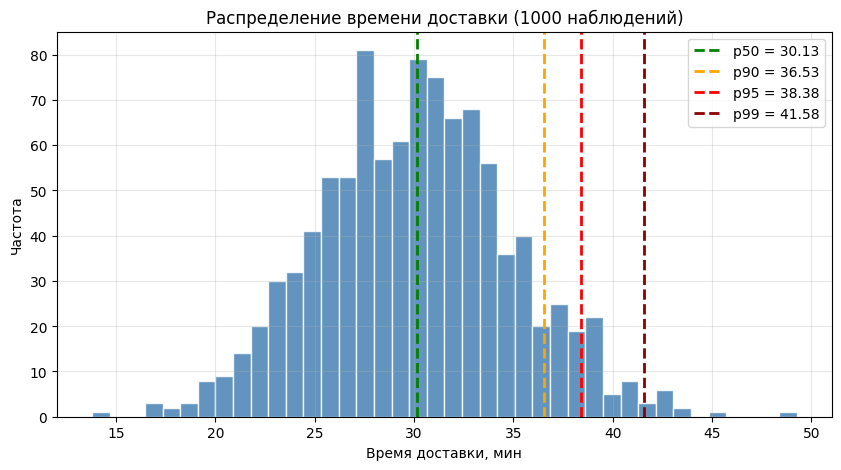

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(delivery_simulated, bins=40, color='steelblue',
         edgecolor='white', alpha=0.85)

# Вертикальные линии процентилей
plt.axvline(p50, color='green', linestyle='--', linewidth=2, label=f'p50 = {p50:.2f}')
plt.axvline(p90, color='orange', linestyle='--', linewidth=2, label=f'p90 = {p90:.2f}')
plt.axvline(p95, color='red', linestyle='--', linewidth=2, label=f'p95 = {p95:.2f}')
plt.axvline(p99, color='darkred', linestyle='--', linewidth=2, label=f'p99 = {p99:.2f}')

plt.title('Распределение времени доставки (1000 наблюдений)')
plt.xlabel('Время доставки, мин')
plt.ylabel('Частота')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Гистограмма показывает распределение времени доставки: большая часть заказов укладывается в 25–35 минут,
# а линии p90, p95 и p99 отмечают границы «длинного хвоста» — редких, но долгих доставок, которые и определяют выполнение SLA.

**Вопросы для анализа**
1. Что означает p90 для времени доставки?
2. Что означает p95?
3. Почему для распределения времени доставки p95 обычно выше p90?
4. Что изменится в управлении логистикой, если компания начнёт ориентироваться не
только на p90, но и на p95?

**Ответ:**

1. p90 = 36.53 означает, что 90% заказов доставляются за 36.53 минут или меньше, а 10% — дольше.
2. p95 = 38.38 означает, что 95% заказов доставляются за 38.38 минут или меньше, а 5% — дольше.
3. Потому что p95 отсекает больше «хвоста» распределения. Чем выше процентиль, тем больше времени доставки он включает.
4. Компания будет уделять больше внимания «длинному хвосту» — редким, но долгим доставкам. Это может потребовать дополнительных курьеров, изменения маршрутов или введения приоритетной доставки для отдалённых районов.

**Продуктовый вывод**

Сформулируйте вывод для менеджера продукта в 2–3 предложениях: выполняется ли SLA; насколько хорошо контролируется длинный хвост распределения.


**Ответ:**

SLA выполняется: 90% заказов доставляются за 36 минут, что меньше заявленных 40 минут. Однако p95 = 38.4 минуты, а p99 = 41.6 минуты — значит, длинный хвост распределения контролируется не идеально: 1% заказов доставляется дольше 41.7 минуты. Для повышения качества стоит обратить внимание на эти редкие, но проблемные случаи.

# Задание 2.3. Разброс и предсказуемость
Две курьерские службы выполнили по пять одинаковых доставок.
service_A = np.array([28, 29, 30, 31, 32]),
service_B = np.array([15, 20, 30, 40, 45])

Для каждой службы рассчитайте: среднее; медиану; стандартное отклонение; 90-й процентиль. При расчёте стандартного отклонения с помощью np.std() используйте стандартное значение ddof=0.

In [ ]:
service_A = np.array([28, 29, 30, 31, 32])
service_B = np.array([15, 20, 30, 40, 45])

for name, service in [("A", service_A), ("B", service_B)]:
    print(f"Служба {name}:")
    print(f"Среднее: {service.mean():.2f}")
    print(f"Медиана: {np.median(service):.2f}")
    print(f"Стандартное отклонение: {service.std():.2f}")
    print(f"90-й процентиль: {np.quantile(service, 0.9):.2f}")

Служба A:
Среднее: 30.00
Медиана: 30.00
Стандартное отклонение: 1.41
90-й процентиль: 31.60
Служба B:
Среднее: 30.00
Медиана: 30.00
Стандартное отклонение: 11.40
90-й процентиль: 43.00


/tmp/ipykernel_6920/437607259.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([service_A, service_B], labels=['Служба A', 'Служба B'],


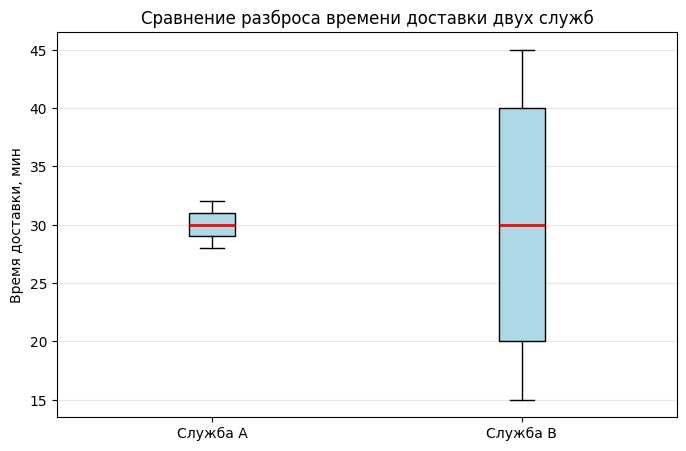

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot([service_A, service_B], labels=['Служба A', 'Служба B'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Сравнение разброса времени доставки двух служб')
plt.ylabel('Время доставки, мин')
plt.grid(alpha=0.3, axis='y')
plt.show()

# Boxplot наглядно показывает, что у службы A узкий «ящик» (разброс 28–32 мин),
# а у службы B — широкий (15–45 мин): при одинаковом среднем служба A предсказуемее,
# что важно для доставки дорогих товаров.

1. Почему одинаковые или близкие средние значения не означают одинаковое качество
работы?
2. Какая служба является более предсказуемой?
3. Какую службу вы выбрали бы для доставки дорогой электроники?
4. Какие статистические показатели повлияли бы на ваше решение?

**Ответ:**

1. Средние равны (30), но разброс разный. Служба A доставляет стабильно от 28 до 32 минут, а служба B — от 15 до 45 минут. Для клиента важна предсказуемость.
2. Служба A является более предсказуемой, так как у неё стандартное отклонение 1.41 против 11.40 у B.
3. Для доставки дорогой электроники выбрали бы службу A, так как она обеспечивает стабильное время доставки, что снижает риск повреждения или кражи при длительной перевозке.
4. Для решения я бы использовала стандартное отклонение (разброс), 90-й процентиль (максимальное время для большинства заказов) и медиану.

# Задание 2.4. Корреляция
Предположим, что увеличение количества товаров в заказе может приводить к увеличению времени его обработки и доставки. Сгенерируйте данные.
1. Рассчитайте коэффициент корреляции Пирсона между items и
delivery_time_correlated с помощью np.corrcoef().
2. Извлеките коэффициент r.
3. Определите: направление связи; силу линейной связи.
4. Сформулируйте возможное объяснение наблюдаемой зависимости с точки зрения
работы склада и доставки.

In [ ]:
np.random.seed(42)
items = np.random.randint(1, 10, 100)
delivery_time_correlated = (
    20
    + 3 * items
    + np.random.normal(0, 3, 100)
)

# 1-2. Коэффициент корреляции Пирсона
corr_matrix = np.corrcoef(items, delivery_time_correlated)
r = corr_matrix[0, 1]
print(f"Коэффициент корреляции r: {r:.4f}")

# 3. Направление и сила связи
print(f"Направление: {'положительная' if r > 0 else 'отрицательная'}")
print(f"Сила связи: {'сильная' if abs(r) > 0.7 else 'средняя' if abs(r) > 0.3 else 'слабая'}")

# 4. Наблюдаемая зависимость с точки зрения работы склада и доставки работает следующим образом -
# чем больше товаров в заказе, тем больше времени требуется на сборку, упаковку и проверку комплектации.
# Это увеличивает общее время доставки. Складские процессы и логистика напрямую зависят от количества позиций в заказе.

Коэффициент корреляции r: 0.9343
Направление: положительная
Сила связи: сильная


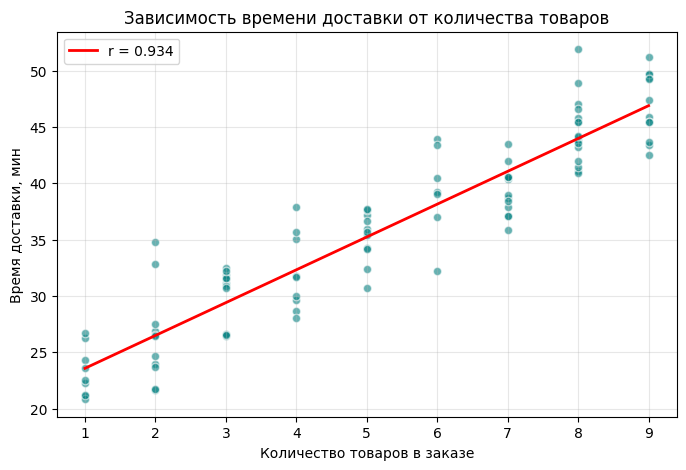

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(items, delivery_time_correlated, color='teal',
            alpha=0.6, edgecolor='white')

# Линия тренда
z = np.polyfit(items, delivery_time_correlated, 1)
x_line = np.linspace(items.min(), items.max(), 100)
plt.plot(x_line, z[0] * x_line + z[1], color='red', linewidth=2,
         label=f'r = {r:.3f}')

plt.title('Зависимость времени доставки от количества товаров')
plt.xlabel('Количество товаров в заказе')
plt.ylabel('Время доставки, мин')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Диаграмма рассеяния с линией тренда показывает сильную положительную линейную связь (r ≈ 0.93):
# чем больше товаров в заказе, тем дольше доставка — что объясняется временем на сборку и упаковку.

**Вопрос для анализа**

Можно ли на основании высокого значения корреляции утверждать:
«Увеличение количества товаров является причиной увеличения времени доставки»?
Объясните ответ.

**Ответ:**

Нет, высокий коэффициент корреляции не доказывает причинно-следственную связь. Корреляция показывает лишь статистическую взаимосвязь. Для доказательства причинности нужен контролируемый эксперимент, где мы изменяем только количество товаров и наблюдаем за временем доставки, исключая влияние других факторов (например, загруженности курьера, погоды, расстояния).

# Задание 2.5. Корреляция и скрытые факторы
Рассмотрим ситуацию:
Летом одновременно увеличиваются: продажи мороженого; количество несчастных случаев на воде. На основании этих данных аналитик делает вывод: «Продажа мороженого приводит к увеличению количества несчастных случаев на воде».

1. Объясните, почему высокая корреляция не доказывает наличие причинно-следственной
связи.
2. Определите фактор, который может влиять одновременно на оба показателя.
3. Объясните механизм возникновения наблюдаемой корреляции.
4. Приведите собственный пример ложной корреляции из бизнеса, технологий, медиа или повседневной жизни.

**Ответ:**

1. Корреляция может быть вызвана третьим фактором, который влияет на оба показателя одновременно. Это называется ложной корреляцией (spurious correlation).
2. Лето (тёплая погода) — оно влияет и на продажи мороженого (люди покупают больше мороженого), и на количество несчастных случаев на воде (люди чаще купаются).
3. Летом температура повышается → люди покупают мороженое → продажи растут. Одновременно люди чаще идут на пляж → увеличивается число купальщиков → растёт число несчастных случаев. Мороженое и несчастные случаи не связаны напрямую, но оба зависят от температуры.
4. Урожай клубники и урожай малины растут одновременно летом. Клубника не влияет на малину, но обе зависят от тепла, солнца и количества осадков. В жаркое солнечное лето обе культуры дают больше плодов — отсюда высокая корреляция без причинной связи.

# **Блок 3. Bootstrap и статистические гипотезы**
# Задание 3.1. Bootstrap и доверительный интервал
На складе измерили время сборки шести заказов:
x = np.array([28, 31, 29, 45, 32, 30])
1. Рассчитайте среднее значение исходной выборки.
2. Реализуйте Bootstrap с количеством итераций: B = 5000.
На каждой итерации: сформируйте выборку такого же размера, как x; используйте выборку с возвращением; рассчитайте её среднее; сохраните результат. Для формирования Bootstrap-выборки используйте: np.random.choice()
3. Получите центральный 95%-й доверительный интервал для среднего с помощью: np.quantile() Используйте квантили: 0.025, 0.975
4. Выведите полученный доверительный интервал.

In [ ]:
import numpy as np
x = np.array([28, 31, 29, 45, 32, 30])

# 1. Среднее исходной выборки
print("Среднее исходной выборки:", x.mean())

# 2. Bootstrap
np.random.seed(42)
B = 5000
bootstrap_means = np.array([
    np.random.choice(x, size=x.size, replace=True).mean()
    for _ in range(B)
])

# 3. Доверительный интервал
ci_lower = np.quantile(bootstrap_means, 0.025)
ci_upper = np.quantile(bootstrap_means, 0.975)

# 4. Вывод
print(f"95%-й доверительный интервал: [{ci_lower:.2f}; {ci_upper:.2f}]")

Среднее исходной выборки: 32.5
95%-й доверительный интервал: [29.17; 37.67]


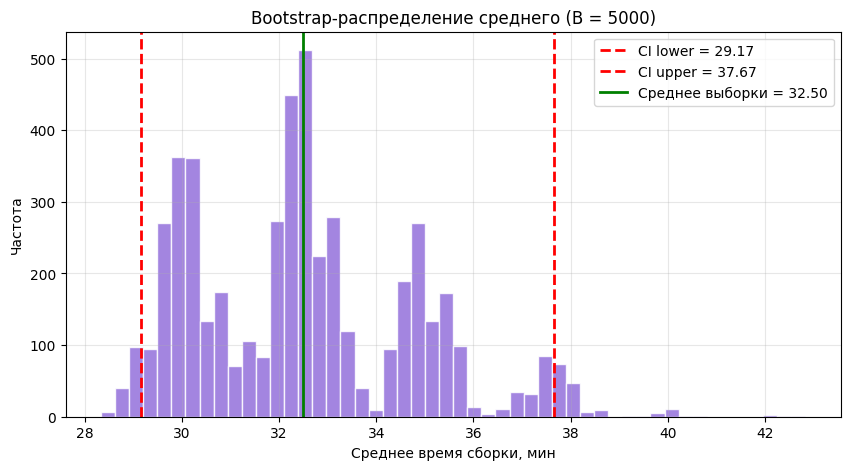

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=50, color='mediumpurple',
         edgecolor='white', alpha=0.85)

plt.axvline(ci_lower, color='red', linestyle='--', linewidth=2,
            label=f'CI lower = {ci_lower:.2f}')
plt.axvline(ci_upper, color='red', linestyle='--', linewidth=2,
            label=f'CI upper = {ci_upper:.2f}')
plt.axvline(x.mean(), color='green', linestyle='-', linewidth=2,
            label=f'Среднее выборки = {x.mean():.2f}')

plt.title('Bootstrap-распределение среднего (B = 5000)')
plt.xlabel('Среднее время сборки, мин')
plt.ylabel('Частота')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Гистограмма показывает bootstrap-распределение среднего: оно близко к нормальному,
# а красные линии отмечают 95%-й доверительный интервал — диапазон, в который с высокой вероятностью попадает истинное среднее при повторных выборках.

**Вопросы для анализа**
1. Почему Bootstrap используется именно с выборкой с возвращением?
2. Как наличие наблюдения 45 влияет на Bootstrap-распределение среднего?
3. Почему результаты Bootstrap могут заметно изменяться при использовании очень
маленькой исходной выборки?
4. Можно ли утверждать:
«Вероятность того, что истинное среднее находится внутри рассчитанного 95%-го
доверительного интервала, равна 95%»?
Если нет, сформулируйте корректную интерпретацию доверительного интервала.

**Ответ:**

1. Выборка с возвращением имитирует процесс случайного извлечения из генеральной совокупности. Если бы мы выбирали без возвращения, мы бы всегда получали одну и ту же выборку (просто в другом порядке), и не могли бы оценить изменчивость.
2. Наблюдение 45 — выброс. При bootstrap-выборках оно может попасть несколько раз или не попасть вовсе. Это создаёт «тяжёлый хвост» в распределении средних и расширяет доверительный интервал.
3. При малом размере выборки каждый элемент оказывает большое влияние на среднее. Случайные fluctuations при resampling приводят к большей изменчивости оценок.
4. Нет, нельзя утверждать, что «вероятность того, что истинное среднее внутри интервала, равна 95%». Корректно: если мы будем повторять эксперимент много раз и каждый раз строить 95%-й ДИ, то в 95% случаев истинное среднее попадёт в этот интервал. Для конкретного интервала [28.83; 37.00] мы говорим, что он построен методом, который в 95% случаев накрывает истинное среднее.

# Задание 3.2. Формулировка гипотез и ошибки I и II рода
Продуктовая команда внедрила новый алгоритм распределения заказов между курьерами.
Цель алгоритма — уменьшить среднее время доставки.
Обозначим: \mu_A — истинное среднее время доставки в контрольной группе;
\mu_B — истинное среднее время доставки в группе с новым алгоритмом.
1. Сформулируйте нулевую гипотезу H_0
2. Сформулируйте альтернативную гипотезу H_1.
3. Объясните применительно к этому эксперименту: что означает ошибка I рода; что означает ошибка II рода.
4. Укажите, какая ошибка соответствует: ложной тревоге; пропущенному эффекту.

**Ответ:**

1. H_0: mu_A = mu_B — новый алгоритм не изменил среднее время доставки (средние в контрольной и экспериментальной группах равны).
2. H_1: mu_B < mu_A — новый алгоритм уменьшил среднее время доставки.
3. Ошибка I рода: отвергнуть H_0, когда она верна. То есть признать новый алгоритм эффективным, хотя на самом деле он не уменьшает время доставки. Ошибка II рода: не отвергнуть H_0, когда она неверна. То есть не признать новый алгоритм эффективным, хотя на самом деле он уменьшает время доставки.
4. Ложная тревога = ошибка I рода — «эффект есть», а его нет. Пропущенный эффект = ошибка II рода — «эффекта нет», а он есть.

**Ситуация для анализа**

Полноценная эксплуатация нового алгоритма обходится компании в 5 млн рублей в год.
Какая ошибка может привести к прямым напрасным расходам компании — ошибка I или
ошибка II рода?
Обоснуйте ответ.

**Ответ:**

Прямые напрасные расходы компании (5 млн руб./год) возникнут, если мы внедрим алгоритм, который на самом деле не работает. Это ошибка I рода — мы отвергли H_0 (решили, что алгоритм эффективен), хотя на самом деле это не так. Компания потратит 5 млн рублей на эксплуатацию бесполезного решения.

# Задание 3.3. p-value и принятие решения
После проведения A/B-теста статистический критерий дал: p-value = 0.001. Уровень значимости: α = 0.05
1. Дайте определение p-value.
2. Объясните, почему утверждение:
«p-value = 0.001 означает, что вероятность истинности нулевой гипотезы равна 0.1%» является неверным.
3. Определите, является ли результат статистически значимым при $\alpha = 0.05$.

In [ ]:
# 1. p-value — это вероятность получить такие или более экстремальные результаты при условии,
# что нулевая гипотеза верна. Но это не является вероятностью истинности H_0.

# 2. p-value = 0.001 означает: если H_0 верна, вероятность наблюдать такие данные (или более экстремальные)
# составляет 0.1%. H_0 либо истинна, либо нет — у неё нет вероятности в частотной статистике.

# 3. Результат статистически значим при α = 0.05, так как 0.001 < 0.05.
p_value = 0.001
alpha = 0.05
print(f"p-value = {p_value}")
print(f"α = {alpha}")
print(f"Результат статистически значим: {p_value < alpha}")

p-value = 0.001
α = 0.05
Результат статистически значим: True


**Ситуация для анализа**

Предположим, эксперимент проведён на 1 000 000 пользователей.
Новый алгоритм уменьшил среднее время доставки всего на 3 секунды. При этом статистический критерий дал: p-value = 0.001. Эксплуатация нового алгоритма стоит компании 5 млн рублей в год.

**Вопросы**
1. Является ли результат статистически значимым?
2. Достаточно ли одного p-value для принятия решения о внедрении?
3. Почему статистическая значимость не обязательно означает практическую или бизнесзначимость?
4. Какие дополнительные показатели необходимо учитывать перед раскаткой алгоритма
на всех пользователей?

**Ответ:**

1. Да, результат статистически значим. p-value = 0.001 < α = 0.05, значит, мы отклоняем нулевую гипотезу. Разница между группами не объясняется случайностью — эффект статистически обнаружим. При этом важно понимать, что на такой огромной выборке (1 млн пользователей) даже микроскопические различия становятся статистически значимыми. Мощность теста очень высока, поэтому p-value почти автоматически будет маленьким.
2. Нет, категорически недостаточно. p-value говорит только о том, насколько данные несовместимы с нулевой гипотезой. Он ничего не говорит о величине эффекта (3 секунды — это много или мало?); о стоимости внедрения; о влиянии на пользователей; о побочных эффектах (например, на разброс времени доставки). Решение о внедрении — это бизнес-решение, а не только статистическое. Нужно сопоставить выгоду с затратами.
3. Статистическая значимость проверяет наличие эффекта. Практическая значимость показывает, насколько этот эффект велик и нужно ли что-то менять. На 1 млн наблюдений эффект в 3 секунды статистически значим, но: 3 секунды — это меньше 0.1% от среднего времени доставки (если среднее ~30 мин = 1800 сек, то 3 сек ≈ 0.17%); пользователь вряд ли заметит такое изменение; но компания заплатит 5 млн руб./год.
4. Перед раскаткой на всех пользователей нужно проверить: размер эффекта (effect size), доверительный интервал, разброс (std, IQR), сегментацию, ROI, риски, долгосрочный эффект.

# **Итоговый продуктовый вывод**
Представьте, что вы отвечаете за принятие решения о внедрении алгоритма.
Сформулируйте итоговую рекомендацию и обоснуйте её с использованием трёх
составляющих принятия решения:
1. Статистическая значимость — насколько убедительны данные с точки зрения
статистического критерия.
2. Размер и практическая значимость эффекта — насколько изменение существенно
для пользователя и продукта.
3. Экономическая целесообразность — превышает ли ожидаемый эффект затраты,
риски и стоимость эксплуатации решения.

**Ответ:**

По совокупности трёх составляющих — статистической значимости, практической значимости и экономической целесообразности — я рекомендую не внедрять алгоритм на всех пользователях в текущем виде, а сначала провести дополнительный анализ.

Статистически результат убедителен: p-value = 0.001 при α = 0.05 и выборке в 1 млн пользователей означает, что разница между группами вряд ли случайна. Однако статистическая достоверность ещё не говорит о ценности изменения.

Практическая значимость низкая: улучшение всего на 3 секунды на фоне десятков минут доставки пользователь не заметит, и на NPS, удовлетворённость или поведение клиента это вряд ли повлияет.

Экономическая целесообразность тоже под вопросом: эксплуатация стоит 5 млн рублей в год, и если эти 3 секунды не конвертируются в рост конверсии, повторных покупок или снижение оттока, внедрение обернётся чистыми убытками.

Итог: нужен расчёт ROI. Если 3 секунды не превращаются в деньги через retention, LTV или снижение нагрузки на поддержку, внедрять алгоритм нецелесообразно. Перед решением стоит провести сегментный анализ (возможно, в отдельных группах эффект больше), проверить p90 и p95 (не ухудшился ли «хвост»), оценить долгосрочный эффект на горизонте 2–4 недель и посчитать, сколько должна стоить одна сэкономленная секунда, чтобы окупить 5 млн рублей в год.

# **Итоговый вопрос лабораторной работы**
Представьте, что вы получили набор данных о работе интернет-магазина.
Среднее время доставки уменьшилось после изменения алгоритма, но одновременно: вырос разброс времени доставки; p90 практически не изменился; p95 увеличился; статистический тест показал p-value < 0.05.

Сформулируйте, какие дополнительные вопросы вы зададите перед тем, как рекомендовать внедрение изменения на всех пользователей. В ответе отдельно рассмотрите: качество данных; размер эффекта; распределение результатов; выбросы; процентили; статистическую значимость; практическую значимость; бизнес-эффект.

# Ответ:
Среднее улучшилось, но за счёт «хвоста» распределения. Возможно, алгоритм ускорил «лёгкие» заказы и замедлил «сложные». Пользователи в худшей группе страдают сильнее, чем раньше.

# Дополнительные вопросы перед внедрением:
1. Качество данных:
- Как собирались данные? Нет ли пропусков, дубликатов, ошибок логирования?
- Одинаковые ли условия сбора в контрольной и тестовой группах?
- Как долго длился эксперимент? Не поймали ли мы сезонный эффект?
- Случайна ли разбивка на группы? Нет ли пересечений по пользователям?

2. Размер эффекта:
- На сколько именно изменилось среднее в абсолютных и относительных величинах?
- Какой доверительный интервал у эффекта? Не «размазан» ли он?
- Насколько изменение заметно для пользователя (в ощущениях, а не в числах)?
- Есть ли эффект на ключевые бизнес-метрики (конверсия, повторные заказы, отток)?

3. Распределение результатов:
- Как изменилась форма распределения? Не стало ли оно бимодальным?
- Какие группы пользователей выиграли, какие проиграли?
- Улучшилось ли медианное время доставки? (медиана — честнее среднего при выбросах)
- Изменился ли IQR (межквартильный размах)?

4. Выбросы:
- Увеличилось ли число экстремально долгих доставок?
- Откуда взялись новые выбросы — технические сбои, человеческий фактор, пиковая нагрузка?
- Не «съедают» ли выбросы весь положительный эффект на среднем?
- Что происходит с заказами в топ-1% по длительности?

5. Процентили:
- Почему p90 не изменился, а p95 вырос? Что это говорит о «длинном хвосте»?
- Как изменились p99, p99.9? Насколько тяжёлым стал хвост?
- Сколько пользователей попадает в зону p95+? Это приемлемо для бизнеса?
- Соответствует ли новое распределение заявленному SLA (90% за 40 минут)?

6. Статистическая значимость
- p-value < 0.05 — но какой размер выборки? На большой выборке даже мусор значим.
- Какой тест применялся? Корректен ли он для распределений времени (обычно не нормальных)?
- Учтена ли проблема множественных сравнений (если смотрели много метрик)?
- Есть ли статистическая значимость по p95, а не только по среднему?

7. Практическая значимость
- Заметит ли пользователь изменение? Станет ли он чаще заказывать?
- Улучшится ли NPS, CSAT, retention?
- Не ухудшится ли опыт «медленного» сегмента настолько, что это перевесит выгоду?
- Соответствует ли изменение продуктовой стратегии (скорость vs. стабильность)?

8. Бизнес-эффект
- Как изменится LTV, выручка, маржинальность?
- Окупятся ли затраты на эксплуатацию (5 млн руб. и т.д.)?
- Сколько будет стоить поддержка и мониторинг нового алгоритма?
- Какие риски репутационных потерь, если «медленные» доставки станут ещё медленнее?
- Есть ли альтернативные решения той же задачи (дешевле, безопаснее)?